<>:69: SyntaxWarning: invalid escape sequence '\.'
<>:69: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_5191/1417994318.py:69: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


Shape: (891, 12)

Columns:
 ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Describe:
        PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   


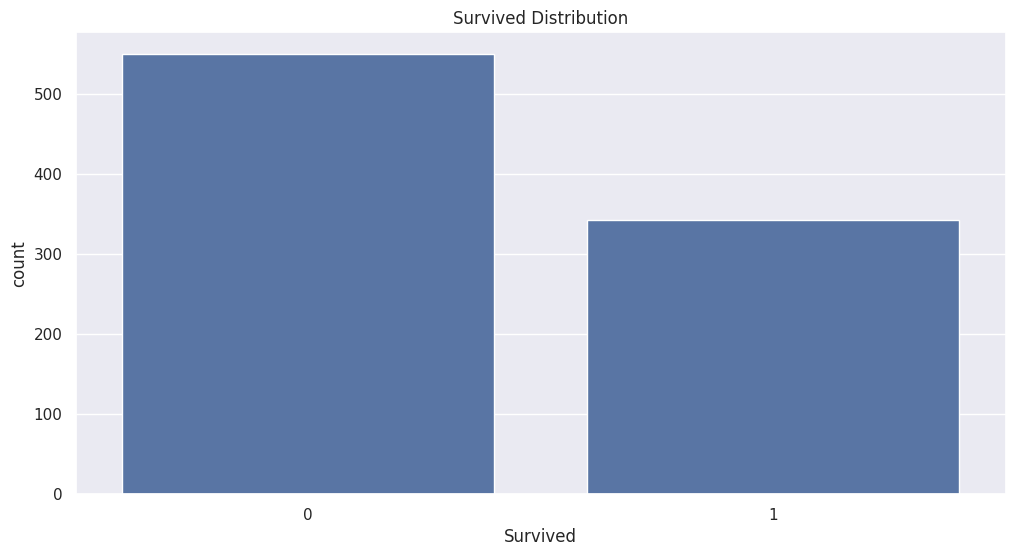

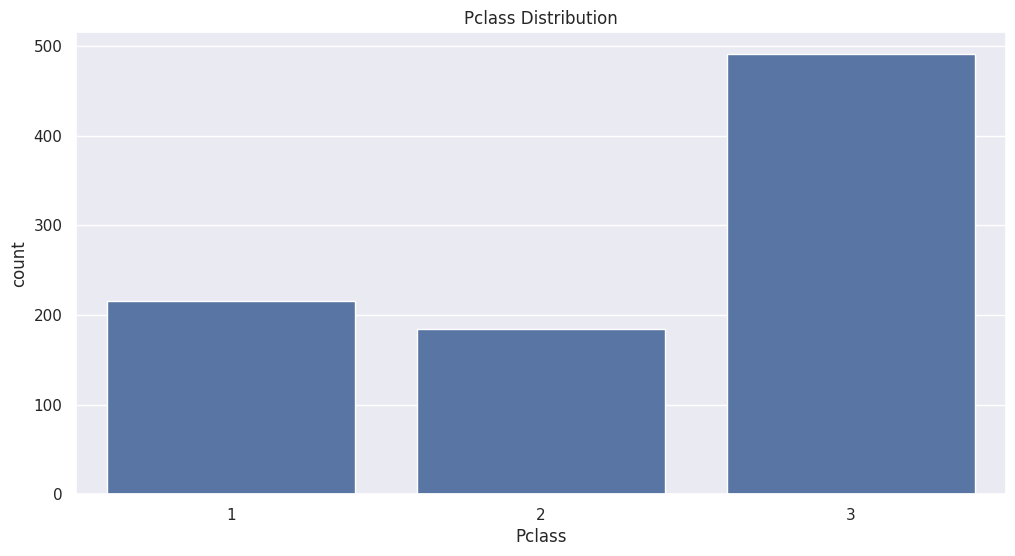

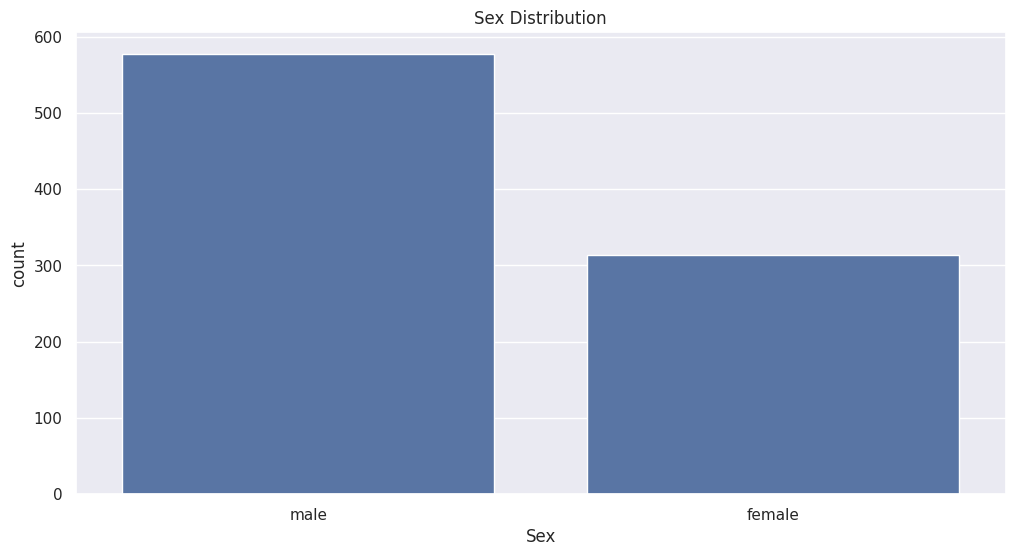

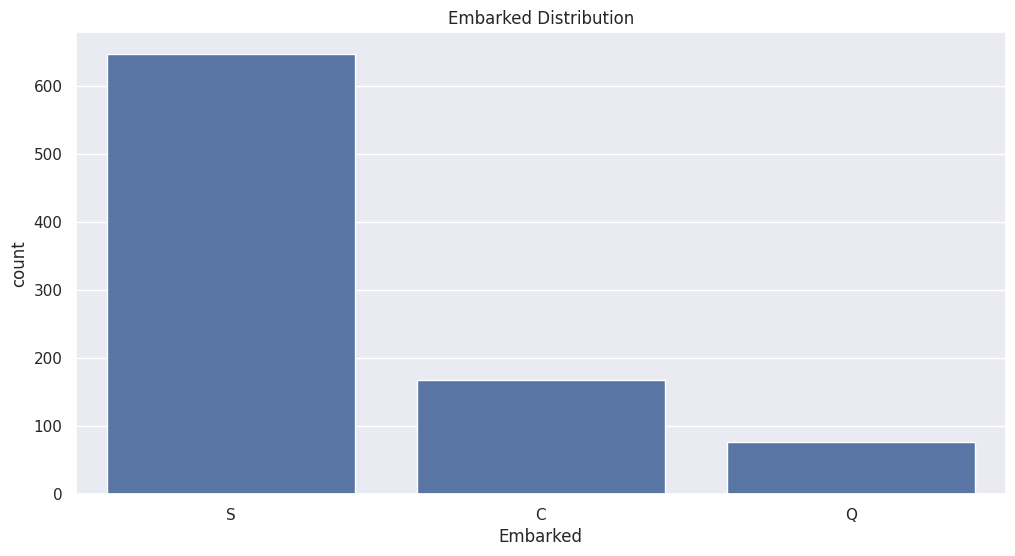

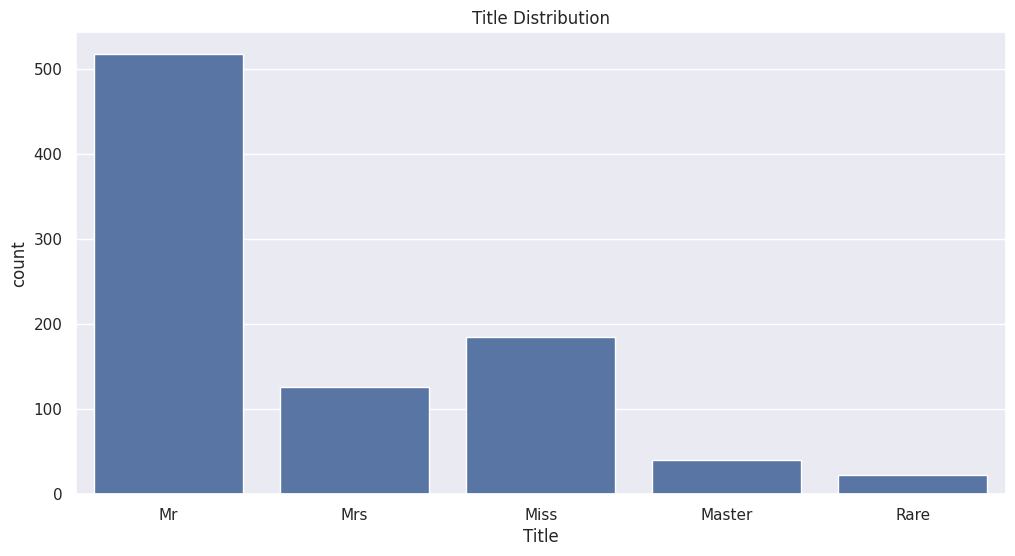

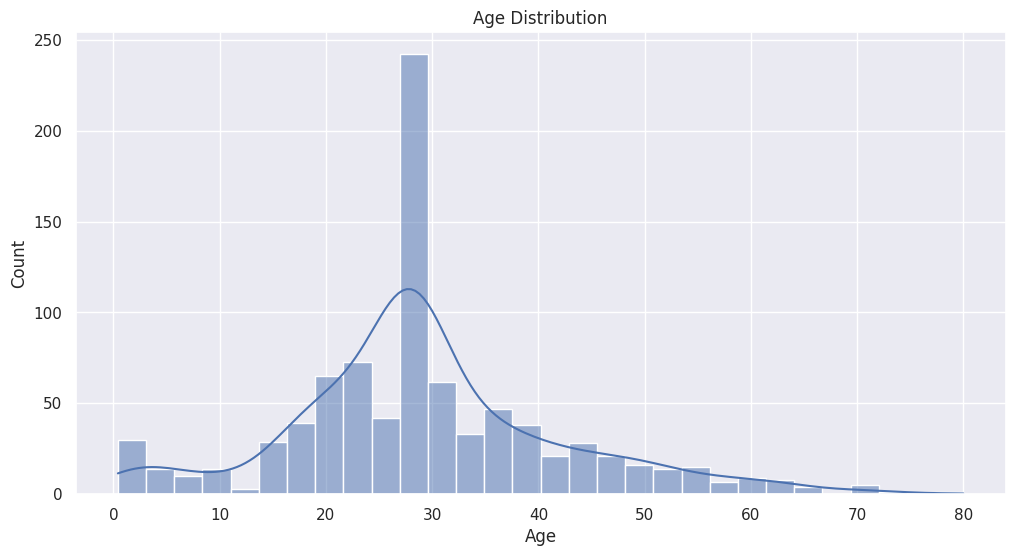

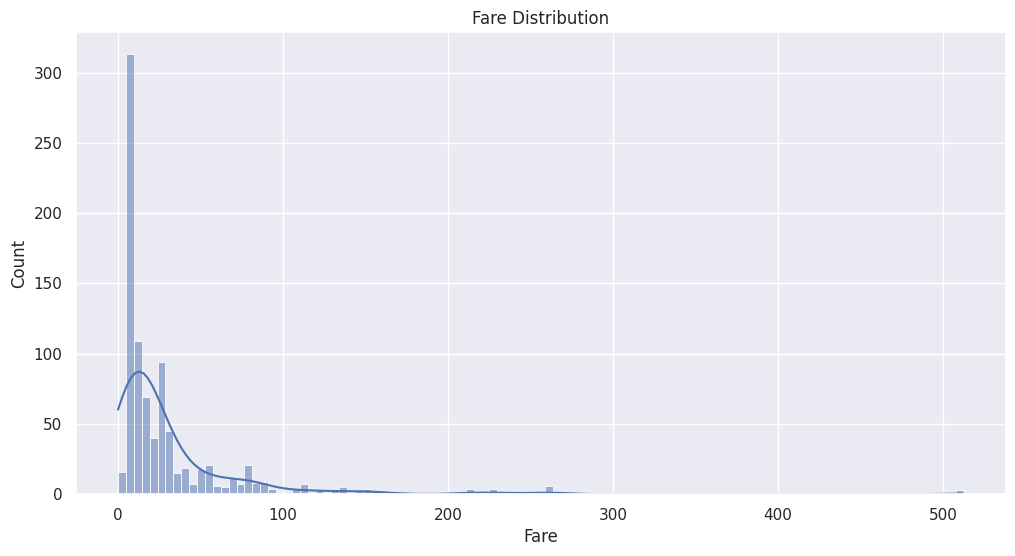

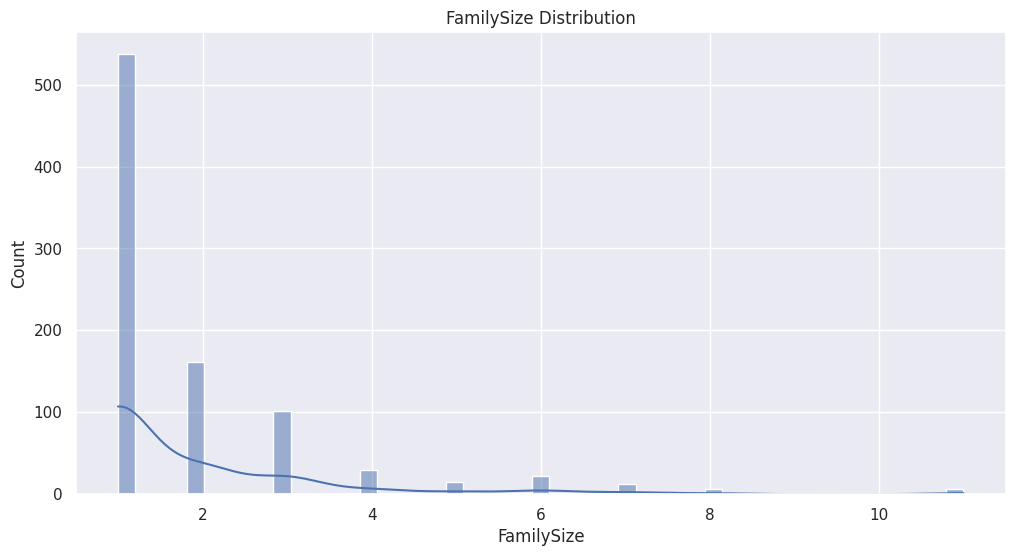

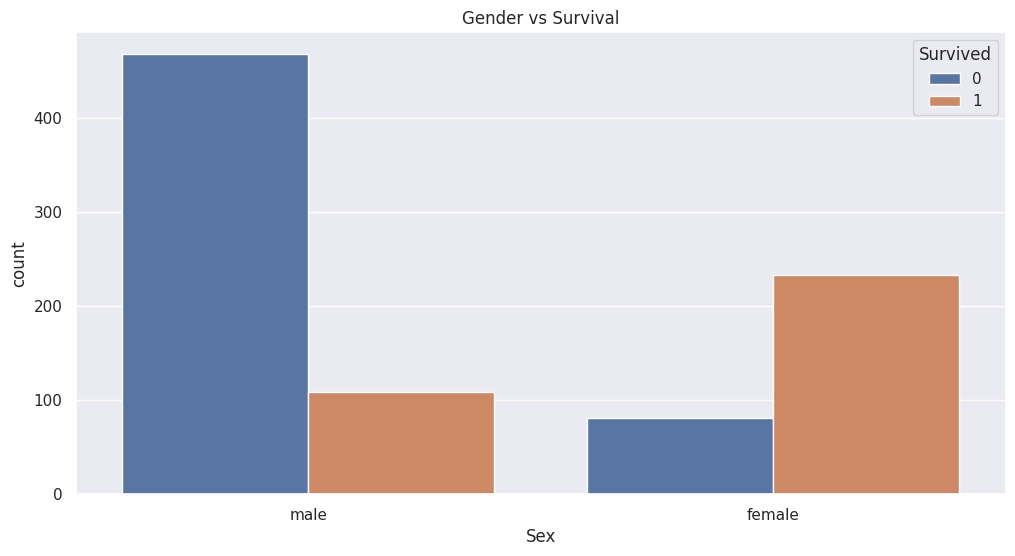

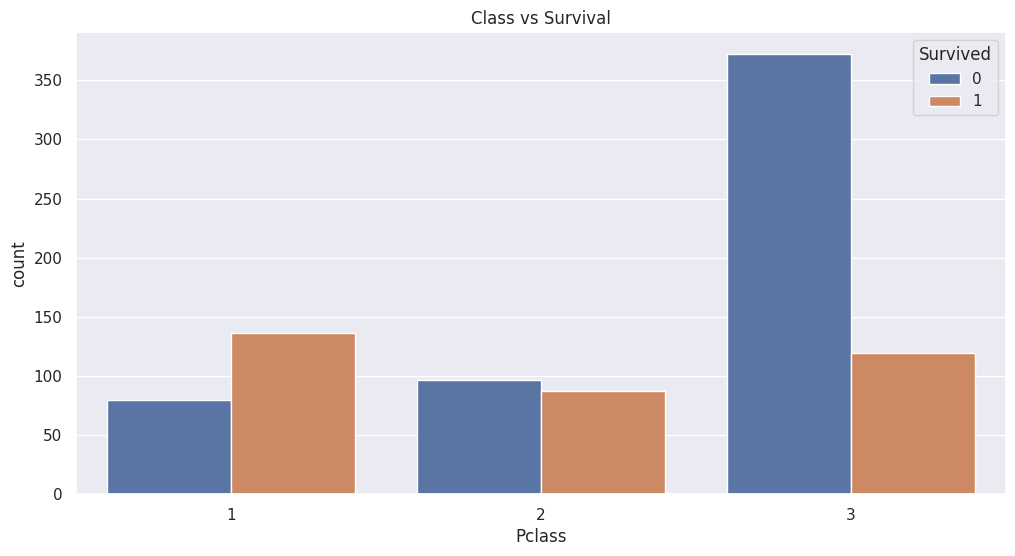

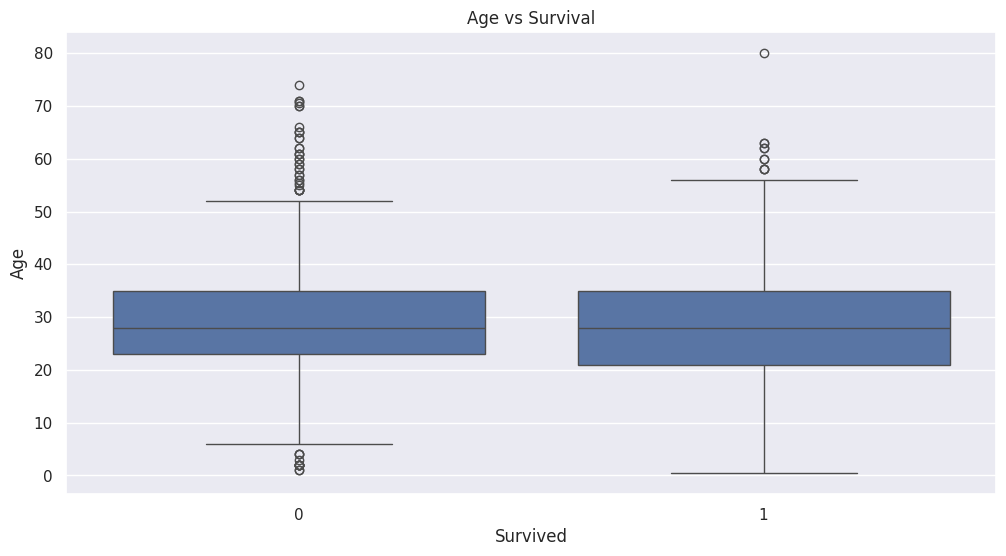

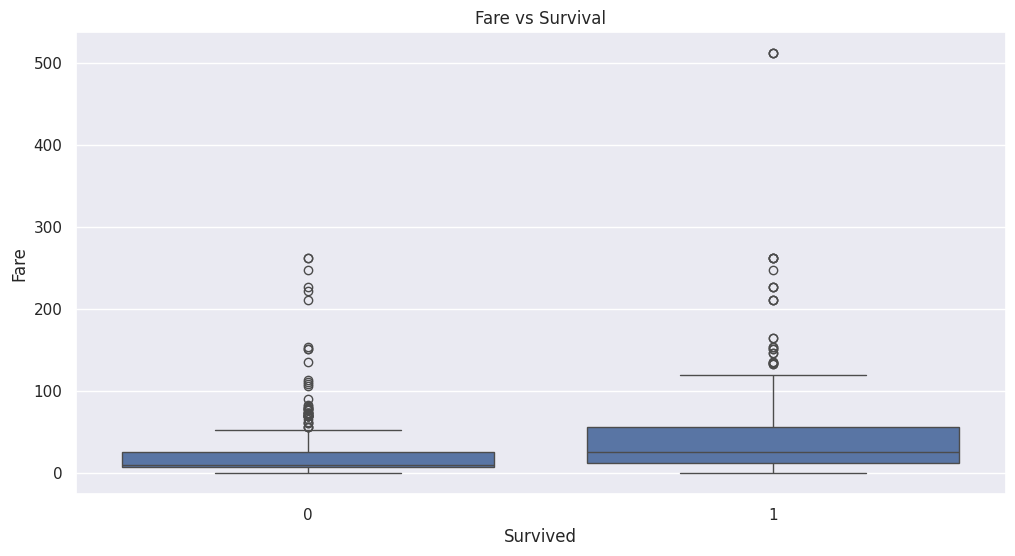

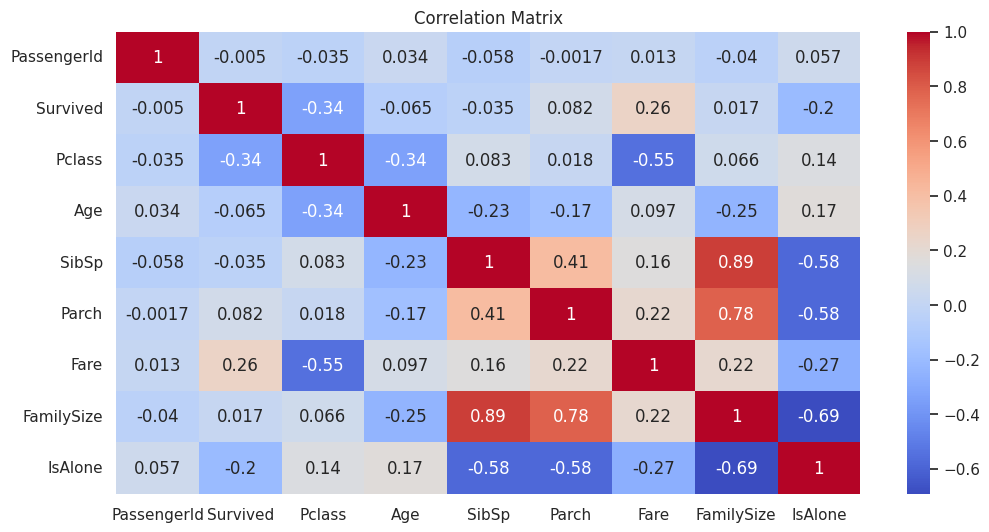

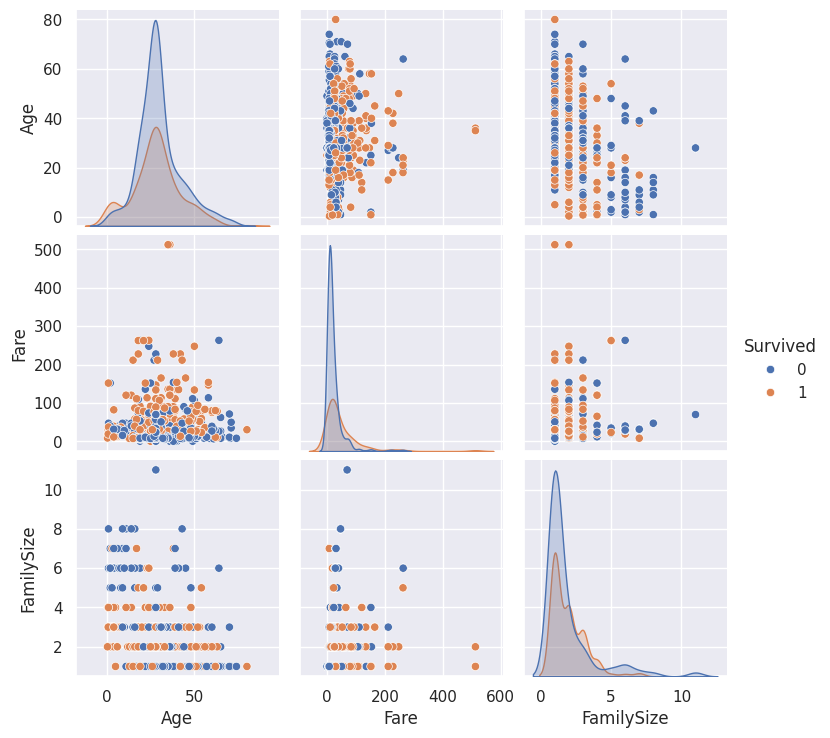

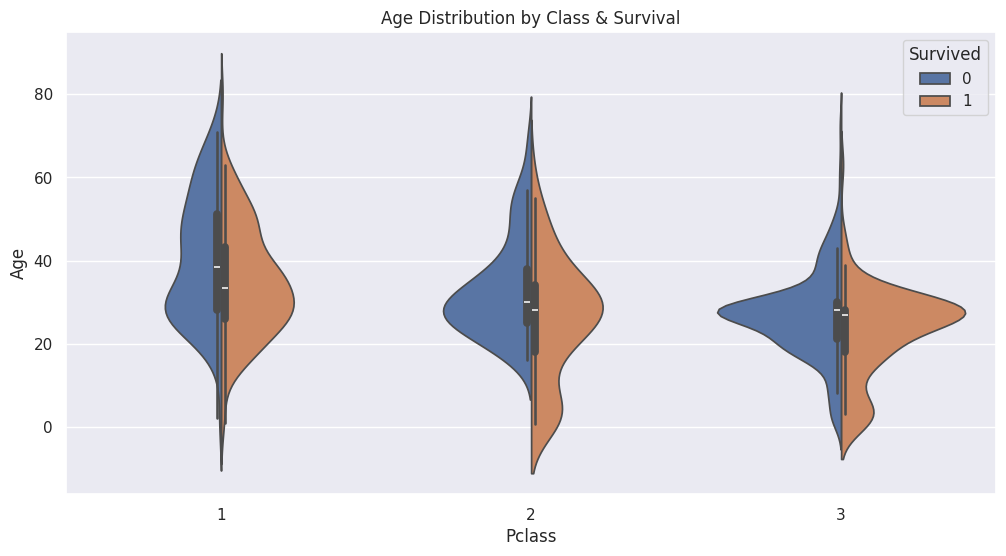

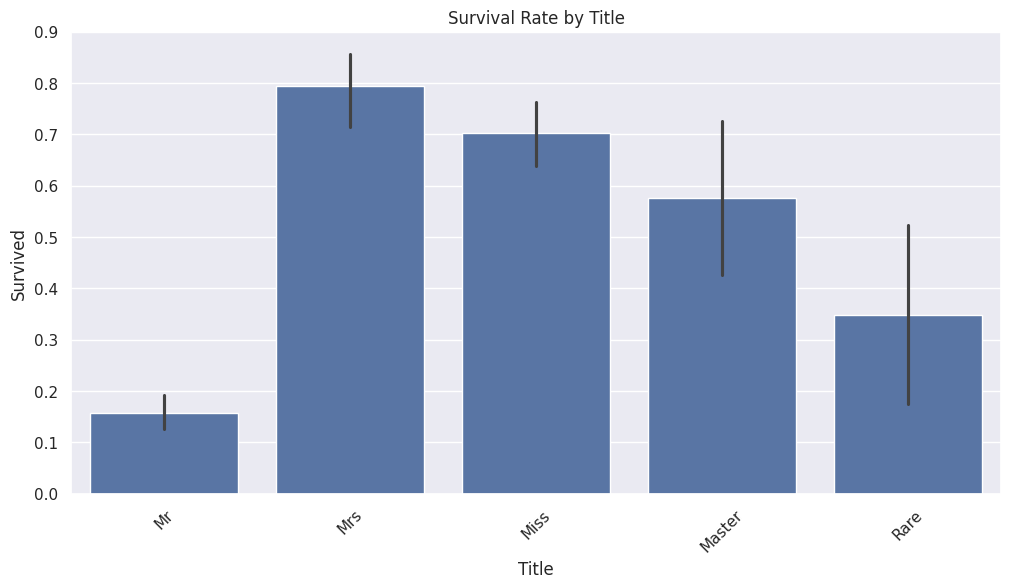

T-Test Age vs Survival:
T-stat: -1.9394659179476366 P-value: 0.0527606884758555

Chi-Square Test Sex vs Survival:
Chi2: 260.71702016732104 P-value: 1.1973570627755645e-58


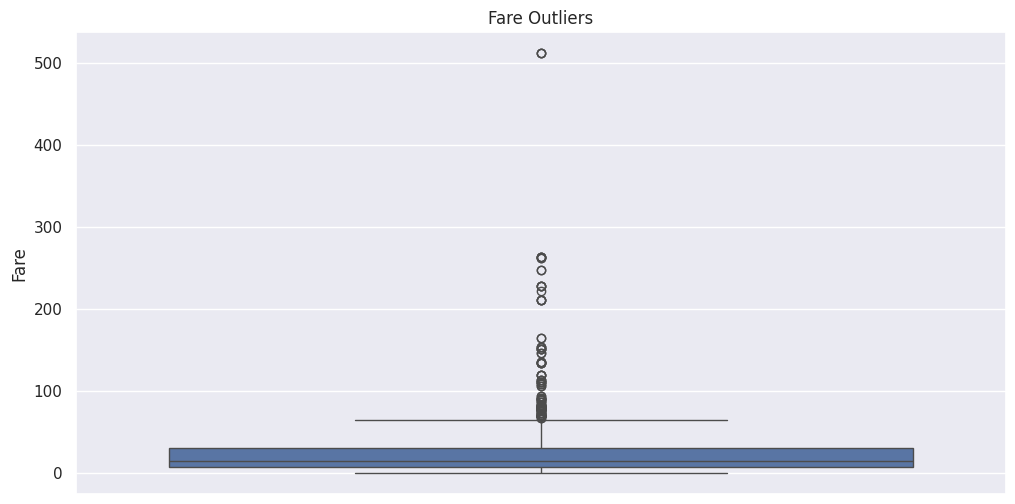


🔥 FINAL INSIGHTS:
✔ Females survived more than males
✔ Higher class passengers had better survival
✔ Fare positively correlates with survival
✔ Small families survived more
✔ Titles like 'Mrs' and 'Miss' had higher survival


In [1]:
# =====================================================
# 🔥 TITANIC EDA - ADVANCED INDUSTRY LEVEL PROJECT
# =====================================================

# ===============================
# 1. IMPORT LIBRARIES
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats

sns.set(style="darkgrid")
plt.rcParams['figure.figsize'] = (12,6)

# ===============================
# 2. LOAD DATA
# ===============================
def load_data():
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    return df

df = load_data()

# ===============================
# 3. BASIC OVERVIEW
# ===============================
def basic_overview(df):
    print("Shape:", df.shape)
    print("\nColumns:\n", df.columns.tolist())
    print("\nData Types:\n", df.dtypes)
    print("\nMissing Values:\n", df.isnull().sum())
    print("\nDescribe:\n", df.describe())

basic_overview(df)

# ===============================
# 4. DATA CLEANING
# ===============================
def clean_data(df):
    df = df.copy()

    df['Age'].fillna(df['Age'].median(), inplace=True)
    df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
    df.drop(columns=['Cabin'], inplace=True)

    return df

df = clean_data(df)

# ===============================
# 5. FEATURE ENGINEERING
# ===============================
def feature_engineering(df):
    df = df.copy()

    # Family size
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

    # Is Alone
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # Title extraction
    df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

    # Title grouping
    df['Title'] = df['Title'].replace(
        ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')

    df['Title'] = df['Title'].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})

    # Age bins
    df['AgeGroup'] = pd.cut(df['Age'],
                           bins=[0,12,18,35,60,100],
                           labels=['Child','Teen','Young','Adult','Senior'])

    # Fare bins
    df['FareGroup'] = pd.qcut(df['Fare'], 4, labels=['Low','Medium','High','Very High'])

    return df

df = feature_engineering(df)

# ===============================
# 6. UNIVARIATE ANALYSIS
# ===============================
def univariate_analysis(df):

    cols = ['Survived','Pclass','Sex','Embarked','Title']

    for col in cols:
        sns.countplot(x=col, data=df)
        plt.title(f"{col} Distribution")
        plt.show()

    # Numerical
    num_cols = ['Age','Fare','FamilySize']

    for col in num_cols:
        sns.histplot(df[col], kde=True)
        plt.title(f"{col} Distribution")
        plt.show()

univariate_analysis(df)

# ===============================
# 7. BIVARIATE ANALYSIS
# ===============================
def bivariate_analysis(df):

    sns.countplot(x='Sex', hue='Survived', data=df)
    plt.title("Gender vs Survival")
    plt.show()

    sns.countplot(x='Pclass', hue='Survived', data=df)
    plt.title("Class vs Survival")
    plt.show()

    sns.boxplot(x='Survived', y='Age', data=df)
    plt.title("Age vs Survival")
    plt.show()

    sns.boxplot(x='Survived', y='Fare', data=df)
    plt.title("Fare vs Survival")
    plt.show()

bivariate_analysis(df)

# ===============================
# 8. MULTIVARIATE ANALYSIS
# ===============================
def multivariate_analysis(df):

    corr = df.corr(numeric_only=True)
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title("Correlation Matrix")
    plt.show()

    sns.pairplot(df[['Survived','Age','Fare','FamilySize']], hue='Survived')
    plt.show()

multivariate_analysis(df)

# ===============================
# 9. ADVANCED VISUALS
# ===============================
def advanced_visuals(df):

    sns.violinplot(x='Pclass', y='Age', hue='Survived', data=df, split=True)
    plt.title("Age Distribution by Class & Survival")
    plt.show()

    sns.barplot(x='Title', y='Survived', data=df)
    plt.title("Survival Rate by Title")
    plt.xticks(rotation=45)
    plt.show()

advanced_visuals(df)

# ===============================
# 10. STATISTICAL TESTS
# ===============================
def statistical_tests(df):

    # T-test: Age vs Survival
    survived = df[df['Survived']==1]['Age']
    not_survived = df[df['Survived']==0]['Age']

    t_stat, p_val = stats.ttest_ind(survived, not_survived)

    print("T-Test Age vs Survival:")
    print("T-stat:", t_stat, "P-value:", p_val)

    # Chi-square: Sex vs Survival
    contingency = pd.crosstab(df['Sex'], df['Survived'])
    chi2, p, dof, ex = stats.chi2_contingency(contingency)

    print("\nChi-Square Test Sex vs Survival:")
    print("Chi2:", chi2, "P-value:", p)

statistical_tests(df)

# ===============================
# 11. OUTLIER DETECTION
# ===============================
def outlier_detection(df):

    sns.boxplot(df['Fare'])
    plt.title("Fare Outliers")
    plt.show()

outlier_detection(df)

# ===============================
# 12. FINAL INSIGHTS
# ===============================
def final_insights():
    print("\n🔥 FINAL INSIGHTS:")
    print("✔ Females survived more than males")
    print("✔ Higher class passengers had better survival")
    print("✔ Fare positively correlates with survival")
    print("✔ Small families survived more")
    print("✔ Titles like 'Mrs' and 'Miss' had higher survival")

final_insights()